In [31]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

In [32]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [33]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

In [34]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

In [35]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

w的L2范数是： 13.79974365234375


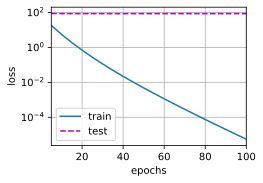

In [36]:
train(lambd=0)

w的L2范数是： 0.012548846192657948


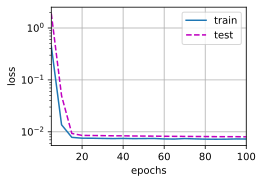

In [37]:
train(lambd=30)

In [38]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())
    print('w的L2范数：', net[0].weight)

w的L2范数： 13.241073608398438
w的L2范数： Parameter containing:
tensor([[-0.0384,  0.1899, -0.1372, -0.5169,  0.8469, -0.8945,  0.0767,  0.7067,
         -1.1953, -0.0747,  1.1666, -1.9204, -0.2276, -0.6356,  0.1698, -0.1749,
         -0.2996, -1.0237, -0.6263,  1.0817,  1.5959,  1.0448, -1.6373,  0.1146,
         -0.7932, -1.2505, -0.4218, -0.8037,  2.2218, -0.3363, -1.6207,  0.5839,
          0.5805, -1.5516, -0.7639,  0.9333,  0.2627, -1.4075,  0.6356,  0.0723,
          0.2254, -0.6491,  0.8923, -1.3318,  0.1593, -0.6508,  1.0501,  0.5471,
          1.7334, -1.4707, -1.5658, -1.2753,  0.1868, -0.7131,  1.6778, -0.4674,
          0.5987, -0.1984,  0.2950,  0.6624, -1.7629, -0.1352,  2.1387, -0.1496,
          0.4975,  0.3048,  0.9065, -1.3528, -0.9074, -0.1600,  0.3301, -1.1348,
         -1.1817,  1.4460,  1.1945,  1.5348, -0.0629, -1.1608, -0.9600, -0.6331,
          0.4428, -0.4715, -0.9669,  0.9048,  1.4736, -0.8506,  0.3102,  1.3589,
         -0.2081, -0.0700,  0.0082, -1.2224, -0.5941

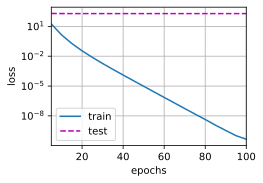

In [39]:
train_concise(0)

w的L2范数： 0.44115352630615234
w的L2范数： Parameter containing:
tensor([[-0.0369,  0.0218,  0.0409, -0.0193, -0.0404,  0.0356, -0.0544, -0.0236,
         -0.0271,  0.0311,  0.0036, -0.0232,  0.0028,  0.0251, -0.0291,  0.0029,
         -0.0190,  0.0668,  0.0334,  0.0234,  0.0337, -0.0104,  0.0195, -0.0231,
          0.0232,  0.0039,  0.0173, -0.0128, -0.0225, -0.0007, -0.0206,  0.0435,
         -0.0155,  0.0421, -0.0154, -0.0363, -0.0578, -0.0280,  0.0485,  0.0270,
         -0.0429, -0.0579, -0.0209,  0.0296,  0.0036, -0.0207,  0.0349,  0.0696,
         -0.0291, -0.0033,  0.0727,  0.0187, -0.0059,  0.0506,  0.0187, -0.0616,
          0.0030,  0.0618, -0.0066, -0.0191,  0.0339,  0.0523,  0.0480, -0.0050,
         -0.0054, -0.0223, -0.0393, -0.0341,  0.0190,  0.0275,  0.0478,  0.0278,
          0.0103,  0.0098, -0.0111,  0.0052, -0.0127,  0.0301, -0.0106, -0.0257,
          0.0378,  0.0189,  0.0289,  0.0287,  0.0662,  0.0068, -0.0060,  0.0112,
         -0.0519, -0.0086, -0.0730, -0.0242, -0.005

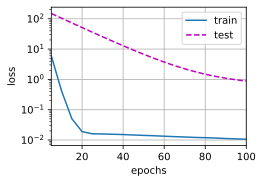

In [40]:
train_concise(3)